In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# PB 215

In [2]:
# For x = np.array([5, 15, 25, 35, 45, 55]) and y = np.array([5, 20, 14, 32, 22, 38]), apply simple linear regression using scikit learn
# library and calculate calculate R squared, coeficient and intercept. Predict the y values for x = np.arange(5). (Don't split data for
# training/testing)

In [3]:
x = np.array([5, 15, 25, 35, 45, 55])
y = np.array([5, 20, 14, 32, 22, 38])

In [4]:
Y = pd.Series(y)
X = pd.DataFrame(x)

In [5]:
X

,0
0,5
1,15
2,25
3,35
4,45
5,55


In [6]:
Y

0     5
1    20
2    14
3    32
4    22
5    38
dtype: int64

In [7]:
LR = LinearRegression()
LR.fit(X , Y)

LinearRegression()

In [8]:
x_test = np.arange(5)
x_test

array([0, 1, 2, 3, 4])

In [9]:
y_pred = LR.predict(pd.DataFrame(x_test))
y_pred

array([5.63333333, 6.17333333, 6.71333333, 7.25333333, 7.79333333])

In [10]:
LR.coef_

array([0.54])

In [11]:
LR.intercept_

np.float64(5.633333333333329)

In [12]:
y_pred1 = LR.predict(X)
y_pred1

array([ 8.33333333, 13.73333333, 19.13333333, 24.53333333, 29.93333333,
       35.33333333])

In [13]:
mean_absolute_error(Y , y_pred1)

5.466666666666666

In [14]:
mean_squared_error(Y , y_pred1)

33.75555555555556

In [15]:
r2_score(Y , y_pred1)

0.715875613747954

# PB 216

In [16]:
# Given a dataset with 'SAT' scores as independent variables and 'GPA' as the dependent variable, calculate R squared, coeficient
# and intercept using linear regression and scikitlearn library. (Don't split data for training/testing)

In [17]:
df = pd.read_csv("SATscores.csv")
df.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     100 non-null    int64  
 1   GPA     100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [19]:
x = df[["SAT"]]
y = df["GPA"]

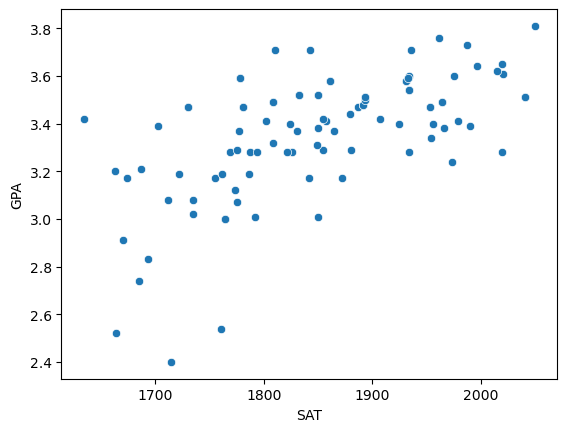

In [20]:
sns.scatterplot(x = df["SAT"] , y = y)
plt.show()

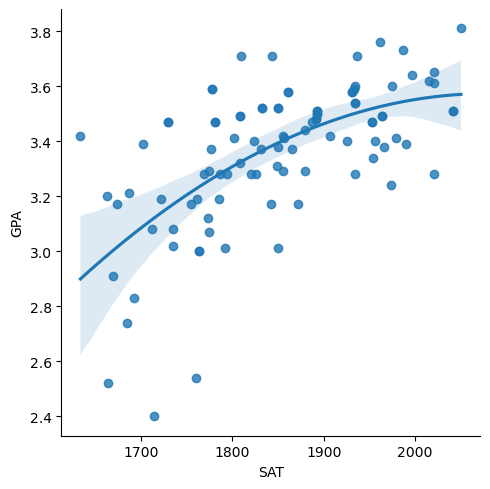

In [21]:
sns.lmplot(data = df , x = "SAT" , y = "GPA" , order=2)
plt.show()

In [22]:
LR = LinearRegression()
LR.fit(x , y)

LinearRegression()

In [23]:
y_pred = LR.predict(x)

In [24]:
r2_score(y , y_pred)

0.37522010676459205

# PB 217

# PB 218

In [25]:
# Predict salary based on job position of 6.5 using polynomial regression with a degree of 3 and scikit learn library for the given
# 'Position_Salaries.csv' dataset. (Don't split data for training/testing)

In [26]:
df = pd.read_csv("Position_Salaries.csv")
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [27]:
x = df[["Level"]]
y = df["Salary"]

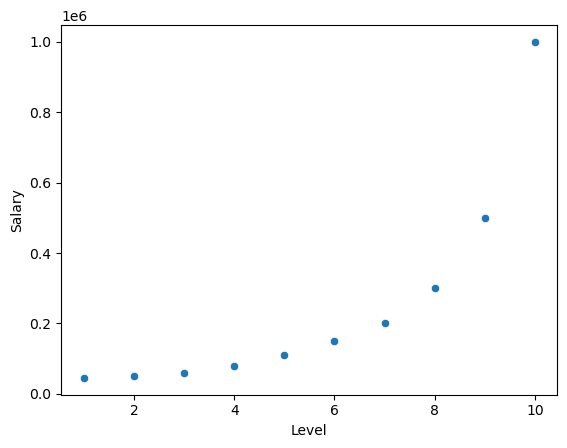

In [28]:
sns.scatterplot(x = df["Level"] , y = df["Salary"])
plt.show()

In [29]:
modelpoly = PolynomialFeatures(degree=3)

In [30]:
x_transform = modelpoly.fit_transform(x)

In [31]:
LR = LinearRegression()
LR.fit(x_transform , y)

LinearRegression()

In [32]:
y_pred = LR.predict(x_transform)

In [33]:
r2_score(y , y_pred)

0.9812097727913367

In [34]:
trans = modelpoly.fit_transform([[6.5]])
print(trans)
print(f"For 6.f level Salary is {LR.predict(trans)}")

[[  1.      6.5    42.25  274.625]]
For 6.f level Salary is [133259.46969697]


# PB 219

In [35]:
#  For x = np.arange(0, 30) and y = np.array([3, 4, 5, 7, 10, 8, 9, 10, 10, 23, 27, 44, 50, 63, 67, 60, 62, 70, 75, 88, 81, 87, 95, 100, 108,
# 135, 151, 160, 169, 179]), apply polynomial regression using scikit learn library and calculate R squared, coeficient and intercept.
# Predict the y values for x = np.arange(5). (Don't split data for training/testing)

In [36]:
x = np.arange(0 , 30)
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [37]:
x = pd.DataFrame(x)

In [38]:
y = np.array([3, 4, 5, 7, 10, 8, 9, 10, 10, 23, 27, 44, 50, 63, 67, 60, 62, 70, 75, 88, 81, 87, 95, 100, 108, 135, 151, 160, 169, 179])
y = pd.Series(y)

In [39]:
model_poly = PolynomialFeatures(degree=2)
x_transform = model_poly.fit_transform(x)
LR = LinearRegression()
LR.fit(x_transform , y)

LinearRegression()

In [40]:
y_pred = LR.predict(x_transform)

In [41]:
r2_score(y , y_pred)

0.9742355121173141

In [42]:
pred_x = pd.DataFrame(np.arange(5))
pred_x_transform = model_poly.fit_transform(pred_x)

In [43]:
print(f"For x is {LR.predict(pred_x_transform)}")

For x is [1.70806452 3.04187987 4.70292388 6.69119657 9.00669792]


# PB 220

In [44]:
# Write a program to make a model based on linear regression for the following dataframe created from a csv file named
# “Package.csv” of x and y which follows equation y = a + bx. Write a program which can predict value of y based on any value of x,
# also write code to find value of a and b in above equation.

In [45]:
df = pd.read_csv("Package.csv")
df

,"cgpa,package"
0,"6.89,3.26"
1,"5.12,1.98"
2,"7.82,3.25"
3,"7.42,3.67"
4,"6.94,3.57"
...,...
195,"6.93,2.46"
196,"5.89,2.57"
197,"7.21,3.24"
198,"7.63,3.96"


In [46]:
if len(df.columns) == 1:
    df = df.iloc[:, 0].str.split(",", expand=True)
    df.columns = ["cgpa", "package"]

In [47]:
df["cgpa"] = df["cgpa"].astype(float)
df["package"] = df["package"].astype(float)

In [48]:
x = df[["cgpa"]]
y = df["package"]

In [49]:
LR = LinearRegression()

In [50]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
LR.fit(x_train , y_train)

LinearRegression()

In [51]:
y_pred = LR.predict(x_test)

In [52]:
r2_score(y_test , y_pred)

0.7730984312051673

In [53]:
LR.coef_

array([0.57425647])

In [54]:
LR.intercept_

np.float64(-1.02700693745421)

In [55]:
print(f"Y = ({LR.coef_})X + ({LR.intercept_})")

Y = ([0.57425647])X + (-1.02700693745421)


# PB 221

In [56]:
# frame created from a csv file named “data.csv” of x1 and y which follows equation y = a+bx1. Write a program which can predict value
# of y based on any value of x, also write code to find value of a and b in above equation. Given Data in csv file:

In [57]:
d={"x1":[60,62,67,70,71,72,75,78],
"y":[140,155,159,179,192,200,212,215]}

In [58]:
df = pd.DataFrame(d)

In [59]:
x1 = df[["x1"]]
y = df["y"]

In [60]:
LR = LinearRegression()
LR.fit(x1 , y)

LinearRegression()

In [61]:
print(f"Y = ({LR.coef_})X + ({LR.intercept_})")

Y = ([4.40549503])X + (-124.1312174324965)


In [62]:
y_pred = LR.predict(x1)
mean_squared_error(y , y_pred)

40.07650402652772

# PB 222

In [63]:
# Write a program to create a Model using linear regression to predict the price of house using the csv file provided named
# “Housing.csv”. Do the required process in the data before making a model. Find predicted values, co-efficients, intercept and
# mean squared error.

In [64]:
df = pd.read_csv("HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [66]:
df.isna().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [67]:
df.dropna(inplace=True)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     394 non-null    float64
 1   ZN       394 non-null    float64
 2   INDUS    394 non-null    float64
 3   CHAS     394 non-null    float64
 4   NOX      394 non-null    float64
 5   RM       394 non-null    float64
 6   AGE      394 non-null    float64
 7   DIS      394 non-null    float64
 8   RAD      394 non-null    int64  
 9   TAX      394 non-null    int64  
 10  PTRATIO  394 non-null    float64
 11  B        394 non-null    float64
 12  LSTAT    394 non-null    float64
 13  MEDV     394 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 46.2 KB


In [69]:
x = df.drop(columns=["MEDV"])
y = df["MEDV"]

In [70]:
LR = LinearRegression()
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
LR.fit(x_train , y_train)

LinearRegression()

In [71]:
y_pred = LR.predict(x_test)

In [72]:
mean_absolute_error(y_test , y_pred)

3.3679832251542425

In [73]:
mean_squared_error(y_test , y_pred)

31.454047664950867

In [74]:
r2_score(y_test , y_pred)

0.6270849941673191

In [75]:
LR.coef_

array([-1.12187394e-01,  4.24404148e-02,  2.56728238e-02,  1.98383708e+00,
       -1.70792571e+01,  4.25809072e+00, -2.17413906e-02, -1.42418883e+00,
        2.35587949e-01, -1.19971379e-02, -9.75834850e-01,  9.59377961e-03,
       -3.88619588e-01])

In [76]:
LR.intercept_

np.float64(33.65240504056529)

# PB 223

In [77]:
# Write a program to create a Model using linear regression to predict the student scores using the csv file provided named
# “student_scores.csv”. Do the required process in the data before making a model. Find predicted values, co-efficients, intercept
# and mean squared error

In [78]:
df = pd.read_csv("student_scores (1).csv")
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [80]:
df.isnull().sum()

Hours     0
Scores    0
dtype: int64

In [81]:
x = df[["Hours"]]
y = df["Scores"]

In [82]:
LR = LinearRegression()
LR.fit(x , y)

LinearRegression()

In [83]:
y_pred = LR.predict(x)

In [84]:
mean_absolute_error(y , y_pred)

4.972805319866375

In [85]:
mean_squared_error(y , y_pred)

28.88273050924546

In [86]:
r2_score(y , y_pred)

0.9529481969048356

In [87]:
LR.coef_

array([9.77580339])

In [88]:
LR.intercept_

np.float64(2.483673405373196)

# PB 224

In [89]:
# Write a program to create a Model using linear regression to predict the gas consumption using the csv file provided named
# “petrol_consumption.csv”. Do the required process in the data before making a model. Find predicted values, co-efficients,
# intercept and mean squared error

In [90]:
df = pd.read_csv("petrol_consumption.csv")
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48 non-null     int64  
 2   Paved_Highways                48 non-null     int64  
 3   Population_Driver_licence(%)  48 non-null     float64
 4   Petrol_Consumption            48 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.0 KB


In [92]:
df.isna().sum()

Petrol_tax                      0
Average_income                  0
Paved_Highways                  0
Population_Driver_licence(%)    0
Petrol_Consumption              0
dtype: int64

In [93]:
df.corr()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
Petrol_tax,1.000000,0.012665,-0.522130,-0.288037,-0.451280
Average_income,0.012665,1.000000,0.050163,0.157070,-0.244862
Paved_Highways,-0.522130,0.050163,1.000000,-0.064129,0.019042
Population_Driver_licence(%),-0.288037,0.157070,-0.064129,1.000000,0.698965
Petrol_Consumption,-0.451280,-0.244862,0.019042,0.698965,1.000000


In [94]:
x = df.drop(columns = ["Petrol_Consumption"])
y = df["Petrol_Consumption"]

In [95]:
LR = LinearRegression()
LR.fit(x , y)

LinearRegression()

In [96]:
y_pred = LR.predict(x)

In [97]:
mean_absolute_error(y , y_pred)

48.77748087708267

In [98]:
mean_squared_error(y , y_pred)

3938.5410046485035

In [99]:
r2_score(y , y_pred)

0.6786867115698209

In [100]:
LR.coef_

array([-3.47901492e+01, -6.65887518e-02, -2.42588889e-03,  1.33644936e+03])

In [101]:
LR.intercept_

np.float64(377.2911464736734)

# PB 225

In [102]:
#  Write a program to create a Model using linear regression to predict the gas consumption using the csv file provided named
# “FuelConsumptionCo2.csv”. Do the required process in the data before making a model. Find predicted values, co-efficients,
# intercept and mean squared error. (Wherever required remove null values, convert categorical data into numeric data) (Print
# Output wherever required)

In [103]:
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [104]:
df2 = df.copy()

In [105]:
df2 = df2.drop(columns = ["MAKE" , "MODEL" , "FUELCONSUMPTION_CITY" , "FUELCONSUMPTION_HWY"])
df2

,MODELYEAR,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,COMPACT,2.0,4,AS5,Z,8.5,33,196
1,2014,COMPACT,2.4,4,M6,Z,9.6,29,221
2,2014,COMPACT,1.5,4,AV7,Z,5.9,48,136
3,2014,SUV - SMALL,3.5,6,AS6,Z,11.1,25,255
4,2014,SUV - SMALL,3.5,6,AS6,Z,10.6,27,244
...,...,...,...,...,...,...,...,...,...
1062,2014,SUV - SMALL,3.0,6,AS6,X,11.8,24,271
1063,2014,SUV - SMALL,3.2,6,AS6,X,11.5,25,264
1064,2014,SUV - SMALL,3.0,6,AS6,X,11.8,24,271
1065,2014,SUV - SMALL,3.2,6,AS6,X,11.3,25,260


In [106]:
df2 = pd.get_dummies(df2)

In [107]:
df2.head()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,VEHICLECLASS_COMPACT,VEHICLECLASS_FULL-SIZE,VEHICLECLASS_MID-SIZE,VEHICLECLASS_MINICOMPACT,...,TRANSMISSION_AV6,TRANSMISSION_AV7,TRANSMISSION_AV8,TRANSMISSION_M5,TRANSMISSION_M6,TRANSMISSION_M7,FUELTYPE_D,FUELTYPE_E,FUELTYPE_X,FUELTYPE_Z
0,2014,2.0,4,8.5,33,196,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2014,2.4,4,9.6,29,221,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2014,1.5,4,5.9,48,136,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,2014,3.5,6,11.1,25,255,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2014,3.5,6,10.6,27,244,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [108]:
x = df2.drop(columns = ["CO2EMISSIONS"])
y = df["CO2EMISSIONS"]

In [109]:
LR = LinearRegression()
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [110]:
LR.fit(x_train , y_train)

LinearRegression()

In [111]:
y_pred = LR.predict(x_test)

In [112]:
y_pred

array([306.51095616, 226.11154564, 293.13576323, 226.26845421,
       208.76291767, 247.99051133, 250.4390154 , 309.62962217,
       310.79087905, 255.54363267, 214.30719653, 386.02992341,
       260.2206541 , 249.30280942, 269.67925472, 258.56661218,
       231.80347217, 246.29412535, 184.59818602, 303.16251497,
       330.77045925, 215.68747568, 267.92583969, 237.2170708 ,
       285.59940428, 197.52976556, 210.55339501, 175.00067871,
       298.36919869, 250.50565141, 358.12951639, 195.1206566 ,
       217.68338179, 350.50568453, 231.57749768, 269.90089845,
       264.74360818, 376.14520953, 196.70359278, 200.72813693,
       150.55043478, 177.194978  , 180.78197337, 210.46137172,
       300.3869506 , 207.89626526, 247.21950548, 279.80478422,
       179.65674461, 392.00348873, 296.63268282, 305.70390554,
       225.01376847, 281.37140068, 291.13664689, 319.55338281,
       355.04734729, 326.50266382, 177.83429279, 292.80718432,
       318.42351777, 275.38699605, 285.49794416, 252.82

In [113]:
mean_absolute_error(y_test , y_pred)

3.445714774609039

In [114]:
mean_squared_error(y_test , y_pred)

32.142869109539525

In [115]:
r2_score(y_test , y_pred)

0.9922265313703484

In [116]:
LR.coef_

array([ 7.08673809e-15,  3.82391969e-01,  1.44710702e+00,  1.76968116e+01,
       -1.63136951e+00,  8.62204128e-01, -1.77634001e+00, -6.45053934e-01,
       -4.37716894e-01, -1.46603063e+00,  2.08896818e-01,  1.78743687e+00,
       -1.81214391e+00,  4.29641734e-01, -1.23058071e+00, -1.13370198e+00,
       -1.26160443e+00,  7.58116430e-01,  7.57956505e-01,  1.79646355e+00,
        3.16245647e+00, -2.95965507e+00,  1.66832613e+00, -6.47059214e-01,
        1.35184511e-01, -1.89098901e-01, -1.09918079e+00,  6.85313920e+00,
        1.23009769e+00, -5.78767250e-01,  3.85510642e-01, -1.26840370e+00,
       -9.42722376e-02, -2.50355081e-01, -9.33505945e-02,  4.03499156e-01,
        2.38772548e+00, -1.34047541e+00,  1.48603578e+00, -2.93844434e+00,
        5.43074445e-01, -2.22441083e-01, -3.41108937e+00,  5.26297019e+01,
       -9.11330067e+01,  1.97838158e+01,  1.87194890e+01])

In [117]:
LR.intercept_

np.float64(74.46636662579127)

# PB 226

In [118]:
# For the given RealEstate csv, write a python program satisfying following tasks to demonstrate application of machine learning
# through multiple linear regression as follows –
# Given: -
# Dataset RealEstate.csv
# ML Library to be used scikit-learn
# Dependent variable 'Y house price of unit area'
# Independent variables 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of
# convenience stores', 'X5 latitude' and 'X6 longitude'
# 1. Import required libraries.
# 2. Load RealEstate dataset, create a dataframe and check datatypes of its attributes using appropriate method.
# 3. Remove ‘No’ column from the dataframe.
# 4. Check for any null values in features using appropriate method.
# 5. Create feature variables x and y as given above.
# 6. Create training and testing sets of feature variables with 70% of data for training and with random state of 110.
# 7. Create and fit regression model using appropriate method.
# 8. Use testing set created in step 6 to find and print the prediction of the outcome.
# 9. Find and print coefficient and mean squared error of the regression model.

In [119]:
df = pd.read_csv("Real estate.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [121]:
df.drop(columns=["No"] , inplace=True)

In [122]:
df.isna().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [123]:
x = df.drop(columns = ["Y house price of unit area"])
y = df["Y house price of unit area"]

In [124]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=42)

In [125]:
LR = LinearRegression()
LR.fit(x_train , y_train)

LinearRegression()

In [126]:
y_pred = LR.predict(x_test)

In [127]:
y_pred

array([47.55430212, 41.08372744, 44.25551663, 40.51685112, 27.43467608,
       45.85435624, 44.70296876, 46.57752144, 23.86072119, 54.35199522,
       34.63011363, 36.34958785, 37.34518438, 23.49428018, 36.02735916,
       34.56828629, 44.01823263, 45.04246804, 29.9554971 , 43.96338099,
        0.09450675, 35.291724  , 48.09455663, 45.54503941, 10.6006418 ,
       39.9786752 , 11.9116313 , 42.79356737, 35.67204264, 38.09573519,
       12.98819108, 40.13164278, 35.44632378, 27.09263458, 46.57230583,
       32.08134705, 50.62714445, 13.2533591 , 49.8007962 , 40.83574406,
       39.02898306, 40.92260381, 47.61743515, 37.68719274, 39.67028734,
       46.64468542, 43.57375428, 19.40851794, 46.95629589, 45.93056809,
       48.03966928, 48.79469044, 43.06419598, 43.00021216, 36.56049741,
       14.20568662, 37.31495695, 34.30916207, 28.33264665, 46.09215428,
       32.92580137, 32.83028385, 14.20568662,  8.3906898 ,  9.79703308,
       34.33939647, 27.76485421, 46.75860125, 33.77722462, 30.85

In [128]:
LR.coef_

array([ 5.84779706e+00, -2.42545813e-01, -5.13873381e-03,  1.07449530e+00,
        2.39096949e+02, -5.22351591e+01])

In [129]:
LR.intercept_

np.float64(-11350.74051877149)

In [130]:
mean_absolute_error(y_test , y_pred)

6.184836340097065

In [131]:
mean_squared_error(y_test , y_pred)

73.56837932850243

In [132]:
r2_score(y_test , y_pred)

0.5600638168604253

### Extra

In [133]:
acc = []
for i in range(146):
    x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=i)
    LR = LinearRegression()
    LR.fit(x_train , y_train)
    y_pred = LR.predict(x_test)
    acc.append(r2_score(y_test , y_pred))

print(max(acc))
print(acc.index(max(acc)))

0.7368487473004253
142


# PB 227

In [134]:
# Write a program to create a Model using linear regression to predict the charges of insurance using the csv file provided named
# “insurance.csv”. Do the required process in the data before making a model. Find predicted values, co-efficients, intercept and
# mean squared error.

In [135]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [136]:
df2 = df.copy()

In [137]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [138]:
df2 = pd.get_dummies(df2)

In [139]:
df2.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [140]:
x = df2[["charges"]]
y = df2["charges"]

In [141]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
LR = LinearRegression()
LR.fit(x_train , y_train)

LinearRegression()

In [142]:
y_pred = LR.predict(x_test)

In [143]:
mean_absolute_error(y_test , y_pred)

5.286437954055145e-12

In [144]:
mean_squared_error(y_test , y_pred)

4.955849703076856e-23

In [145]:
r2_score(y_test , y_pred)

1.0

In [146]:
LR.coef_

array([1.])

In [147]:
LR.intercept_

np.float64(7.275957614183426e-12)

# PB 228

In [148]:
# Write a program to create a Model using linear regression to predict the wine quality using the csv file provided named
# “winequality.csv”. Do the required process in the data before making a model.
# If you find any null value in “winequality.csv” then replace null value with mean value of respected columns.
# Find co-efficient, intercept and mean squared error.
# also Predict the quality of red wine for the following data:
# fixed acidity: 8
# volaƟle acidity: 0.4
# citric acid: 0.40
# residual sugar: 15
# chlorides: 0.048
# free sulfur dioxide: 40
# total sulfur dioxide: 150
# density: 0.99
# pH: 3
# sulphates: 0.45
# alcohol: 10.5

In [149]:
df = pd.read_csv("winequality.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [150]:
df2 = df.drop(columns = ["Id"])

In [151]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [152]:
df2.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [153]:
x = df2.drop(columns = ["quality"])
y = df2["quality"]

In [154]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
LR = LinearRegression()
LR.fit(x_train , y_train)

LinearRegression()

In [155]:
y_pred = LR.predict(x_test)

In [156]:
mean_squared_error(y_test , y_pred)

0.38003245026277527

In [157]:
mean_absolute_error(y_test , y_pred)

0.4773398352588597

In [158]:
r2_score(y_test , y_pred)

0.3170693672733127

In [159]:
LR.coef_

array([ 5.13430654e-02, -1.33625691e+00, -3.39100758e-01,  4.12143173e-03,
       -1.80653035e+00,  1.88076181e-03, -2.28305818e-03, -3.06532562e+01,
       -2.49236344e-01,  9.73040097e-01,  2.66586068e-01])

In [160]:
LR.intercept_

np.float64(34.20980557837856)

In [161]:
given_pred = LR.predict([[8 , 0.4 , 0.40 , 15 , 0.048 , 40 , 150 , 0.99 , 3 , 0.45 , 10.5]])

C:\Users\aditk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [162]:
given_pred

array([5.80087585])

# PB 229

In [163]:
# Consider variables x and y created from a pandas dataframe “car.csv” .
# Create new column named “Age_car” (Age_car=2023-year)
#  For multiple linear regression problem, x contains the independent variables ( Age_car , Driven_kms , Fuel_Type , Selling_type ,
# Transmission ) and y contains the dependent (Selling_Price) variable which is to be predicted.
#  Write a Python program to spilt x and y into training and testing datasets with a 20% split. Then create a multiple linear
# regression model using the training data and print its coefficients ,intercept and mean squared error.

In [164]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [165]:
df["Age_car"] = (2023 - df["Year"])

In [166]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age_car
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,9
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,10
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,6
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,12
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,9


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
 9   Age_car        301 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 23.6+ KB


In [168]:
df2 = df.drop(columns = ["Car_Name"])
df2 = pd.get_dummies(df2)

In [169]:
x = df2.drop(columns=["Selling_Price"])
y = df2["Selling_Price"]

In [170]:
LR = LinearRegression()
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
LR.fit(x_train , y_train)

LinearRegression()

In [171]:
y_pred = LR.predict(x_test)

In [172]:
mean_squared_error(y_test , y_pred)

3.4788039706453935

In [173]:
LR.coef_

array([ 1.76900683e-01,  4.29152503e-01, -6.15725866e-06, -9.03759824e-01,
       -1.76900683e-01, -1.09057894e+00,  1.44269365e+00, -3.52114710e-01,
        5.95296453e-01, -5.95296453e-01,  8.19510777e-01, -8.19510777e-01])

In [174]:
LR.intercept_

np.float64(-352.4070705385307)

# PB 230

In [175]:
# Write a python program for following tasks -
# Make sure all the required libraries are imported at the beginning of the Jupyter Notebook.
# a)Load the windpower dataset into the notebook.
# b)Check records for any missing values and remove them permanently using appropriate method.
# c)Treat windspeed as the independent variable and power as the dependent variable. Split the dataset into training (75%) and
# testing (25%) sets using random state of 42.
# d)Use scikit-learn to train polynomial regression models of degrees 3, 4, 5, and 6.
# e)Predict power values on the test set and print the Mean Squared Error (MSE) and R² score (coefficient of determinaƟon) for
# each polynomial degree.
# f)Plot actual vs. predicted power values for all polynomial degrees on the same graph for comparison and label the plot
# accordingly.
# g)Create a plot showing MSE vs. polynomial degree. Which degree has the lowest MSE? Write in the comment.
# h)Print the coefficients and intercept for each trained polynomial regression model.
# i)Use each model to predict power output for wind speeds of 5, 10, 15, and 20 m/s, and print 

In [206]:
df = pd.read_csv("windpower.csv")
df.head()

,Power (kW),Wind speed (m/s)
0,0.0,0.000
1,0.0,0.125
2,0.0,0.150
3,0.0,0.225
4,0.0,0.275


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Power (kW)        497 non-null    float64
 1   Wind speed (m/s)  495 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [208]:
df.isna().sum()

Power (kW)          3
Wind speed (m/s)    5
dtype: int64

In [209]:
df.dropna(inplace=True)

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 492 entries, 0 to 499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Power (kW)        492 non-null    float64
 1   Wind speed (m/s)  492 non-null    float64
dtypes: float64(2)
memory usage: 11.5 KB


In [211]:
y = df["Power (kW)"]
x = df[["Wind speed (m/s)"]]

In [212]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state=42)

In [213]:
degree = [3 , 4 , 5 , 6]

In [214]:
models = {}
prediction = {}
mse = []
r2 = []

In [215]:
for i in degree:
    poly = PolynomialFeatures(degree=i)

    x_train_trans = poly.fit_transform(x_train)
    x_test_trans = poly.transform(x_test)

    model = LinearRegression()

    model.fit(x_train_trans , y_train)
    y_pred = model.predict(x_test_trans)

    models[i] = model
    prediction[i] = y_pred
    MSE = mse.append(mean_squared_error(y_test , y_pred))
    R2 = r2.append(r2_score(y_test , y_pred))

    print(f"Degree : {i}")
    print(f"MSE for Degree {i} : {MSE}")
    print(f"R2 Score for Degree {i} : {R2}")
    print(f"Coefficient : {model.coef_}")
    print(f"Intercept : {model.intercept_}")

    check = [[5] , [10] , [15] , [20]]
    check_trans = poly.transform(check)
    print(f"Prediction for 5 , 10 , 15 and 20 m/s : {model.predict(check_trans)}\n\n")

Degree : 3
MSE for Degree 3 : None
R2 Score for Degree 3 : None
Coefficient : [  0.         -12.17377575   1.8029668   -0.04960797]
Intercept : 17.775342331041152
Prediction for 5 , 10 , 15 and 20 m/s : [-4.22036222 26.72629808 73.40934798 98.62281223]


Degree : 4
MSE for Degree 4 : None
R2 Score for Degree 4 : None
Coefficient : [ 0.         -2.10494179 -0.036268    0.06568915 -0.00231786]
Intercept : 5.863727006154882
Prediction for 5 , 10 , 15 and 20 m/s : [  1.19480184  23.69809951  70.4887228  103.91393443]


Degree : 5
MSE for Degree 5 : None
R2 Score for Degree 5 : None
Coefficient : [ 0.00000000e+00 -6.91240269e-01 -4.31617906e-01  1.07790122e-01
 -4.21343552e-03  3.03911610e-05]
Intercept : 4.739942925803241
Prediction for 5 , 10 , 15 and 20 m/s : [  1.42863436  23.36063257  70.82208666 103.69098368]


Degree : 6
MSE for Degree 6 : None
R2 Score for Degree 6 : None
Coefficient : [ 0.00000000e+00  2.39063436e+01 -1.00641730e+01  1.62983192e+00
 -1.17629556e-01  4.01186376e-03 

C:\Users\aditk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\aditk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\aditk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\aditk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


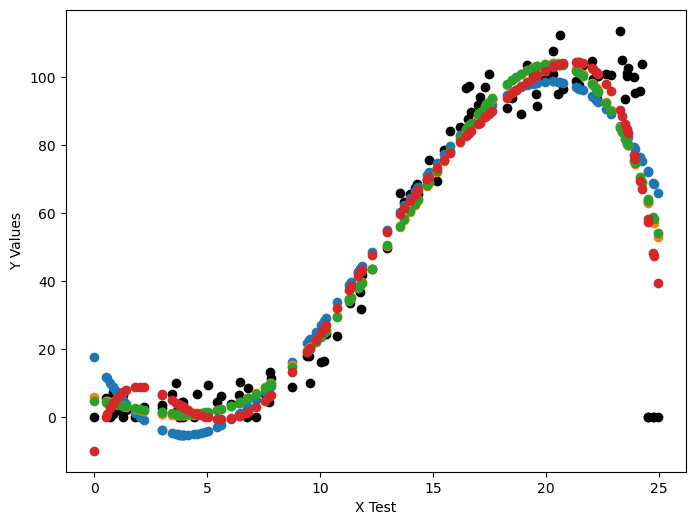

In [216]:
plt.figure(figsize=(8 , 6))
plt.scatter(x = x_test , y = y_test , color="black" , label = "Actual")

for i in degree:
    plt.scatter(x = x_test , y = prediction[i] , label = f"Degree {i}")

plt.xlabel("X Test")
plt.ylabel("Y Values")
plt.show()

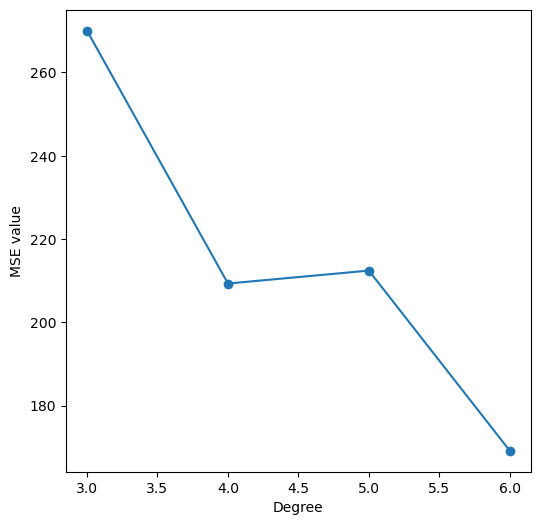

In [218]:
plt.figure(figsize=(6 , 6))
plt.plot(degree , mse , marker='o')
plt.xlabel("Degree")
plt.ylabel("MSE value")
plt.show()

In [220]:
best_deg = degree[mse.index(min(mse))]
print(f"Best Degree according to MSE : {best_deg}")

Best Degree according to MSE : 6
